--- Level 2, Task 1: Table Booking and Online Delivery ---

Percentage offering Table Booking: 12.12%
Percentage offering Online Delivery: 25.66%

Average Rating comparison (Table Booking vs No Table Booking):
Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64


Online Delivery Availability by Price Range (Percentages):
Has Online delivery         No        Yes
Price range                              
1                    84.225923  15.774077
2                    58.689367  41.310633
3                    70.809659  29.190341
4                    90.955631   9.044369


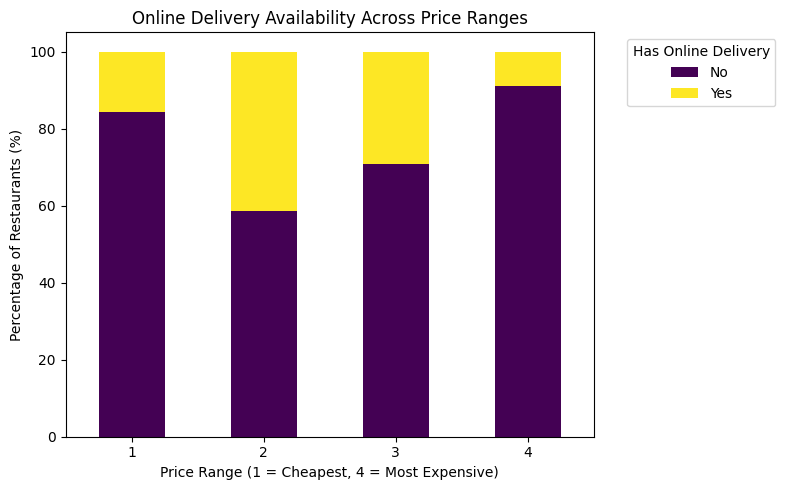

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/Dataset.csv')

print("--- Level 2, Task 1: Table Booking and Online Delivery ---\n")

# 1. Percentage of restaurants offering table booking and online delivery
total_restaurants = len(df)
table_booking_pct = (df['Has Table booking'] == 'Yes').sum() / total_restaurants * 100
online_delivery_pct = (df['Has Online delivery'] == 'Yes').sum() / total_restaurants * 100

print(f"Percentage offering Table Booking: {table_booking_pct:.2f}%")
print(f"Percentage offering Online Delivery: {online_delivery_pct:.2f}%\n")

# 2. Compare average ratings of restaurants with and without table booking
avg_rating_booking = df.groupby('Has Table booking')['Aggregate rating'].mean()
print("Average Rating comparison (Table Booking vs No Table Booking):")
print(avg_rating_booking)
print("\n")

# 3. Analyze availability of online delivery among restaurants with different price ranges
# pd.crosstab calculates the frequency/percentage of delivery options per price range
delivery_by_price = pd.crosstab(df['Price range'], df['Has Online delivery'], normalize='index') * 100

print("Online Delivery Availability by Price Range (Percentages):")
print(delivery_by_price)

# Visualization for your presentation
delivery_by_price.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 5))
plt.title('Online Delivery Availability Across Price Ranges')
plt.xlabel('Price Range (1 = Cheapest, 4 = Most Expensive)')
plt.ylabel('Percentage of Restaurants (%)')
plt.legend(title='Has Online Delivery', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

--- Level 2, Task 2: Price Range Analysis ---

The most common price range among all restaurants is: 1

Average Rating for each Price Range:
Price range
1    2.00
2    2.94
3    3.68
4    3.82
Name: Aggregate rating, dtype: float64


C:\Users\garvi\AppData\Local\Temp\ipykernel_14904\3853439575.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_per_price.index, y=avg_rating_per_price.values, palette='coolwarm')


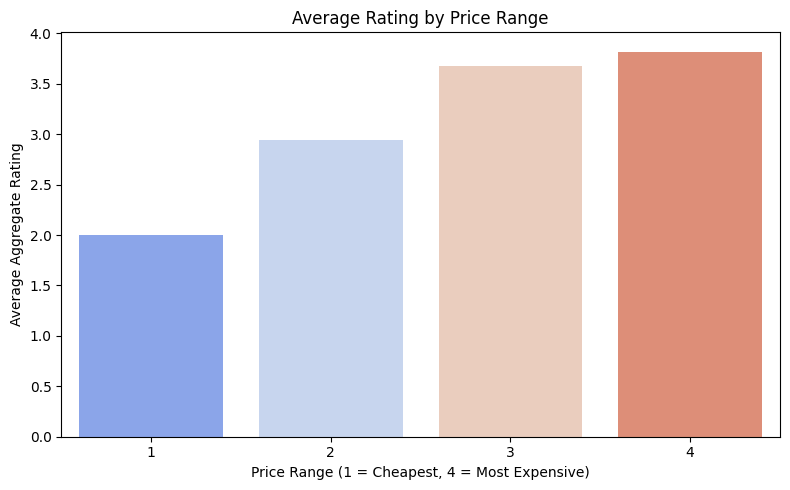


The color representing the highest average rating is 'Dark Green' (Average Rating: 4.66).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (if starting a fresh kernel)
df = pd.read_csv('../data/Dataset.csv')

print("--- Level 2, Task 2: Price Range Analysis ---\n")

# 1. Determine the most common price range
most_common_price_range = df['Price range'].mode()[0]
print(f"The most common price range among all restaurants is: {most_common_price_range}\n")

# 2. Calculate the average rating for each price range
avg_rating_per_price = df.groupby('Price range')['Aggregate rating'].mean().round(2)
print("Average Rating for each Price Range:")
print(avg_rating_per_price)

# Quick visualization for your video/report
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_rating_per_price.index, y=avg_rating_per_price.values, palette='coolwarm')
plt.title('Average Rating by Price Range')
plt.xlabel('Price Range (1 = Cheapest, 4 = Most Expensive)')
plt.ylabel('Average Aggregate Rating')
plt.tight_layout()
plt.show()

# 3. Identify the color that represents the highest average rating
# Grouping by color and finding the maximum mean rating
color_means = df.groupby('Rating color')['Aggregate rating'].mean()
highest_rating_color = color_means.idxmax()
highest_rating_value = color_means.max()

print(f"\nThe color representing the highest average rating is '{highest_rating_color}' (Average Rating: {highest_rating_value:.2f}).")

In [3]:
import pandas as pd

# Load the dataset (if starting a fresh kernel)
df = pd.read_csv('../data/Dataset.csv')

print("--- Level 2, Task 3: Feature Engineering ---\n")

# --- Requirement 1: Extract additional features (Lengths) ---
# Create new columns measuring the character length of names and addresses
df['Restaurant Name Length'] = df['Restaurant Name'].astype(str).apply(len)
df['Address Length'] = df['Address'].astype(str).apply(len)

print("1. Extracted Text Length Features:")
display(df[['Restaurant Name', 'Restaurant Name Length', 'Address', 'Address Length']].head())
print("\n")

# --- Requirement 2: Encode categorical variables ---
# Convert 'Yes' and 'No' to 1 and 0 for future machine learning modeling
df['Has Table Booking (Encoded)'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Has Online Delivery (Encoded)'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

print("2. Encoded Categorical Variables (Yes=1, No=0):")
display(df[['Has Table booking', 'Has Table Booking (Encoded)', 'Has Online delivery', 'Has Online Delivery (Encoded)']].head())
print("\n")

# Pro-Tip: Save this engineered dataset! We can use these new features in Level 3.
df.to_csv('../data/Dataset_Engineered.csv', index=False)
print("Success! Engineered dataset saved as 'Dataset_Engineered.csv' for Level 3.")

--- Level 2, Task 3: Feature Engineering ---

1. Extracted Text Length Features:


,Restaurant Name,Restaurant Name Length,Address,Address Length
0,Le Petit Souffle,16,"Third Floor, Century City Mall, Kalayaan Avenu...",71
1,Izakaya Kikufuji,16,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",67
2,Heat - Edsa Shangri-La,22,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",56
3,Ooma,4,"Third Floor, Mega Fashion Hall, SM Megamall, O...",70
4,Sambo Kojin,11,"Third Floor, Mega Atrium, SM Megamall, Ortigas...",64




2. Encoded Categorical Variables (Yes=1, No=0):


,Has Table booking,Has Table Booking (Encoded),Has Online delivery,Has Online Delivery (Encoded)
0,Yes,1,No,0
1,Yes,1,No,0
2,Yes,1,No,0
3,No,0,No,0
4,Yes,1,No,0




Success! Engineered dataset saved as 'Dataset_Engineered.csv' for Level 3.
